# A2-TempPredict: Temperature Preparation for Simple RNN

This notebook prepares `BASEL_temp_mean` from `Data/weather_prediction_dataset.csv` for a simple PyTorch RNN.

Scenario:
- Feature: `BASEL_temp_mean`
- Sliding window: 14 days
- Forecast horizon: 1 day
- Train/test split: 70% train / 30% test
- 5-fold time-series cross-validation on the training set

## 1. Require setup


In [34]:
# In Google Colab, uncomment the next line if PyTorch is not installed:
# !pip install torch torchvision torchaudio scikit-learn pandas matplotlib

# If your file is in Google Drive, uncomment these two lines:
# from google.colab import drive
# drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
import torch
from torch.utils.data import Dataset, DataLoader
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## 2. Load dataset and inspect the Basel temperature feature

In [35]:
data_path = os.path.join('Data', 'weather_prediction_dataset.csv')
df = pd.read_csv(data_path)
df['DATE'] = pd.to_datetime(df['DATE'].astype(str), format='%Y%m%d')
df = df.sort_values('DATE').reset_index(drop=True)

print('Dataset shape:', df.shape)
print('BASEL_temp_mean exists:', 'BASEL_temp_mean' in df.columns)
print(df[['DATE', 'BASEL_temp_mean']].head(10).to_string(index=False))

Dataset shape: (3654, 165)
BASEL_temp_mean exists: True
      DATE  BASEL_temp_mean
2000-01-01              2.9
2000-01-02              3.6
2000-01-03              2.2
2000-01-04              3.9
2000-01-05              6.0
2000-01-06              4.2
2000-01-07              4.7
2000-01-08              5.6
2000-01-09              4.6
2000-01-10              2.4


In [36]:
missing = df['BASEL_temp_mean'].isna().sum()
print('Missing values:', missing)
print('Value range:', df['BASEL_temp_mean'].min(), 'to', df['BASEL_temp_mean'].max())

Missing values: 0
Value range: -9.3 to 29.0


## 3. Visualize Basel daily mean temperature

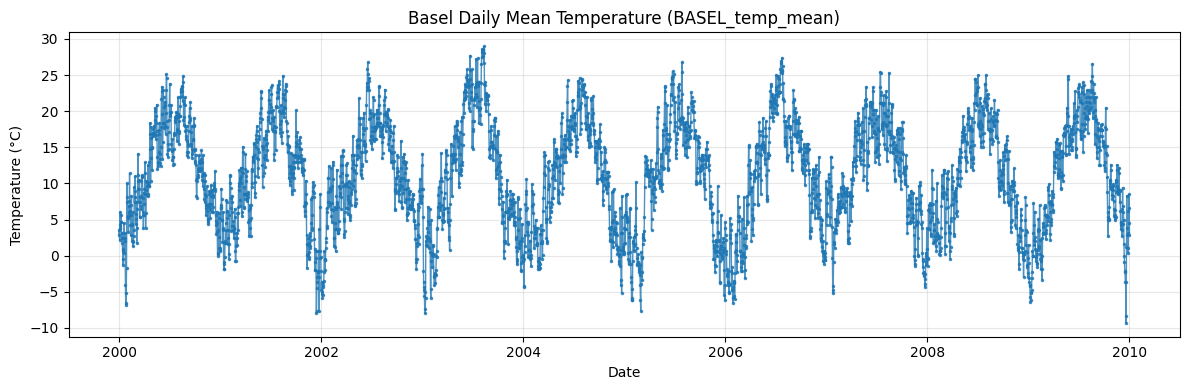

In [37]:
plt.figure(figsize=(12, 4))
plt.plot(df['DATE'], df['BASEL_temp_mean'], marker='.', markersize=3, linewidth=1, alpha=0.8)
plt.title('Basel Daily Mean Temperature (BASEL_temp_mean)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Train/test split (time-order preserved)

Use 70% of the raw series for training and 30% for testing before scaling and windowing. This keeps the split temporal and avoids leakage.

In [38]:
series = df[['DATE', 'BASEL_temp_mean']].dropna().reset_index(drop=True)
values = series['BASEL_temp_mean'].values.reshape(-1, 1)

train_ratio = 0.70
train_size = int(len(values) * train_ratio)
train_values = values[:train_size]
test_values = values[train_size:]

print('Rows after dropna:', len(series))
print('Training rows used for scaling:', len(train_values))
print('Test rows used for scaling:', len(test_values))

Rows after dropna: 3654
Training rows used for scaling: 2557
Test rows used for scaling: 1097


## 5. Normalize and create sliding windows for RNN input

We use a 14-day lookback and predict one day ahead. The model input shape is `(batch, seq_len, features)` with `features = 1`.

In [39]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_values).flatten()
test_scaled = scaler.transform(test_values).flatten()

def create_sliding_windows(data, window_size=14, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size + horizon - 1])
    return np.array(X), np.array(y)

window_size = 14
horizon = 1

train_windows = create_sliding_windows(train_scaled, window_size=window_size, horizon=horizon)
test_windows = create_sliding_windows(test_scaled, window_size=window_size, horizon=horizon)

X_train_full, y_train_full = train_windows[0], train_windows[1]
X_test, y_test = test_windows[0], test_windows[1]

print('Training window samples:', len(X_train_full))

print('Test window samples:', len(X_test))
print('y_train_full shape:', y_train_full.shape)
print('X_train_full shape:', X_train_full.shape)

Training window samples: 2543
Test window samples: 1083
y_train_full shape: (2543,)
X_train_full shape: (2543, 14)


In [ ]:
# Keep the last 20% of the training window set as a simple validation subset.
val_size = max(1, int(0.2 * len(X_train_full)))

X_train, y_train = X_train_full[:-val_size], y_train_full[:-val_size]
X_val, y_val = X_train_full[-val_size:], y_train_full[-val_size:]

print('Training samples:', len(X_train))
print('Validation samples:', len(X_val))
print('Test samples:', len(X_test))
print('Train ratio:', len(X_train) / len(X_train_full))
print('Validation ratio:', len(X_val) / len(X_train_full))

Training samples: 2035
Validation samples: 508
Test samples: 1083
Train ratio: 0.8002359418010224
Validation ratio: 0.19976405819897758


## 6. Prepare training and testing sequence sets

## 8. Create PyTorch dataset and data loaders

In [42]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SequenceDataset(X_train, y_train)
val_dataset = SequenceDataset(X_val, y_val)
test_dataset = SequenceDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

batch_x, batch_y = next(iter(train_loader))
print('Train dataset size:', len(train_dataset))
print('Validation dataset size:', len(val_dataset))
print('Test dataset size:', len(test_dataset))
print('One batch X shape:', batch_x.shape)
print('One batch y shape:', batch_y.shape)

Train dataset size: 2035
Validation dataset size: 508
Test dataset size: 1083
One batch X shape: torch.Size([32, 14, 1])
One batch y shape: torch.Size([32, 1])


## 9. Simple PyTorch RNN model skeleton

In [43]:
class SimpleRNN(torch.nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.rnn = torch.nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = torch.nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        return self.fc(out)

model = SimpleRNN().to(device)
print(model)

SimpleRNN(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


## 10. Train the simple RNN and measure training time

This section trains the model on the 70% training split and measures total training time.


In [44]:
from time import perf_counter
from sklearn.metrics import mean_squared_error, mean_absolute_error

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
n_epochs = 80
patience = 10
history = {'train_loss': [], 'val_loss': [], 'val_mae': []}

best_val_loss = float('inf')
best_state_dict = None
epochs_without_improvement = 0

start_time = perf_counter()
for epoch in range(1, n_epochs + 1):
    model.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x_batch.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    val_mae = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            output = model(x_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item() * x_batch.size(0)
            val_mae += torch.abs(output - y_batch).sum().item()
    val_loss /= len(val_loader.dataset)
    val_mae /= len(val_loader.dataset)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0 or epoch == n_epochs:
        print(f'Epoch {epoch}/{n_epochs}  train_loss={train_loss:.6f}  val_loss={val_loss:.6f}  val_mae={val_mae:.6f}')

    if epochs_without_improvement >= patience:
        print(f'Early stopping triggered at epoch {epoch}.')
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

total_training_time = perf_counter() - start_time
print(f'\nTotal training time: {total_training_time:.2f} seconds')
print(f'Average time per epoch: {total_training_time / max(1, epoch):.4f} seconds')

Epoch 1/80  train_loss=0.136010  val_loss=0.037290  val_mae=0.166028
Epoch 10/80  train_loss=0.006343  val_loss=0.005471  val_mae=0.057843
Epoch 20/80  train_loss=0.004905  val_loss=0.004179  val_mae=0.049886
Epoch 30/80  train_loss=0.004128  val_loss=0.003440  val_mae=0.045131
Epoch 40/80  train_loss=0.003750  val_loss=0.003093  val_mae=0.042305
Epoch 50/80  train_loss=0.003636  val_loss=0.002985  val_mae=0.041322
Epoch 60/80  train_loss=0.003640  val_loss=0.002973  val_mae=0.041133
Early stopping triggered at epoch 67.

Total training time: 12.20 seconds
Average time per epoch: 0.1821 seconds


## 11. Evaluate test performance and compare predictions


Test RMSE (scaled): 0.054906
Test MAE (scaled): 0.043220
Test RMSE (°C): 2.0315
Test MAE (°C): 1.5991
Naive persistence RMSE (°C): 2.1241
Naive persistence MAE (°C): 1.6532


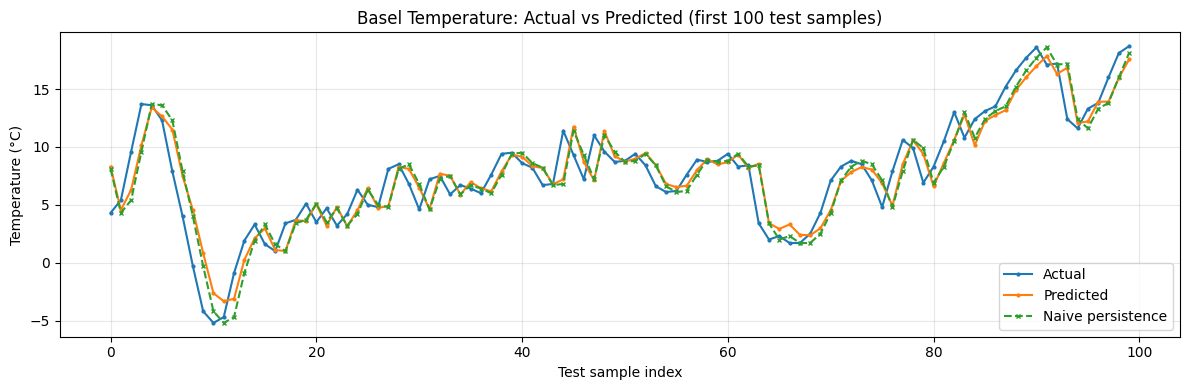

In [45]:
model.eval()
predictions = []
targets = []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        output = model(x_batch).cpu().numpy().flatten()
        predictions.extend(output.tolist())
        targets.extend(y_batch.numpy().flatten().tolist())

predictions = np.array(predictions).reshape(-1, 1)
targets = np.array(targets).reshape(-1, 1)

predictions_inv = scaler.inverse_transform(predictions).flatten()
targets_inv = scaler.inverse_transform(targets).flatten()

naive_scaled = X_test[:, -1].reshape(-1, 1)
naive_predictions_inv = scaler.inverse_transform(naive_scaled).flatten()

rmse_scaled = np.sqrt(mean_squared_error(targets, predictions))
mae_scaled = mean_absolute_error(targets, predictions)
rmse_celsius = np.sqrt(mean_squared_error(targets_inv, predictions_inv))
mae_celsius = mean_absolute_error(targets_inv, predictions_inv)
rmse_baseline = np.sqrt(mean_squared_error(targets_inv, naive_predictions_inv))
mae_baseline = mean_absolute_error(targets_inv, naive_predictions_inv)

print(f'Test RMSE (scaled): {rmse_scaled:.6f}')
print(f'Test MAE (scaled): {mae_scaled:.6f}')
print(f'Test RMSE (°C): {rmse_celsius:.4f}')
print(f'Test MAE (°C): {mae_celsius:.4f}')
print(f'Naive persistence RMSE (°C): {rmse_baseline:.4f}')
print(f'Naive persistence MAE (°C): {mae_baseline:.4f}')

plt.figure(figsize=(12, 4))
plt.plot(targets_inv[:100], label='Actual', marker='.', markersize=4)
plt.plot(predictions_inv[:100], label='Predicted', marker='.', markersize=4)
plt.plot(naive_predictions_inv[:100], label='Naive persistence', linestyle='--', marker='x', markersize=3)
plt.title('Basel Temperature: Actual vs Predicted (first 100 test samples)')
plt.xlabel('Test sample index')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Summary

The Basel temperature dataset is ready for a simple PyTorch RNN model. Continue by adding training/evaluation loops and comparing this scenario with other models.